# Agents with Memory

We have an email assistant that uses a router to triage emails and then passes the email to the agent for response generation. We've also evaluated it and added human-in-the-loop (HITL) to review specific tool calls. Now, we add memory, giving our assistant the ability to remember our HITL feedback!

![overview-img](img/overview_memory.png)

**中文翻译：**

# 带记忆的智能体

我们有一个邮件助理，它使用路由器对邮件进行分流，然后把邮件传给智能体生成回复。我们也已经评估过它，并添加了人在回路 (HITL) 来审查特定工具调用。现在，我们加入记忆，让助理能够记住我们的 HITL 反馈。

![overview-img](img/overview_memory.png)

#### Load Environment Variables

**中文翻译：**

#### 加载环境变量

In [77]:
from dotenv import load_dotenv
load_dotenv("../.env")

False

## Memory in LangGraph

### Thread-Scoped and Across-Thread Memory

First, it's worth explaining how [memory works in LangGraph](https://langchain-ai.github.io/langgraph/concepts/memory/). LangGraph offers two distinct types of memory that serve complementary purposes:

**Thread-Scoped Memory (Short-term)** operates within the boundaries of a single conversation thread. It's automatically managed as part of the graph's state and persisted through thread-scoped checkpoints. This memory type retains conversation history, uploaded files, retrieved documents, and other artifacts generated during the interaction. Think of it as the working memory that maintains context within one specific conversation, allowing the agent to reference earlier messages or actions without starting from scratch each time.

**Across-Thread Memory (Long-term)** extends beyond individual conversations, creating a persistent knowledge base that spans multiple sessions. This memory is stored as JSON documents in a memory store, organized by namespaces (like folders) and distinct keys (like filenames). Unlike thread-scoped memory, this information persists even after conversations end, enabling the system to recall user preferences, past decisions, and accumulated knowledge. This is what allows an agent to truly learn and adapt over time, rather than treating each interaction as isolated.

![short-vs-long-term-memory](img/short-vs-long.png)

The [Store](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore) is the foundation of this architecture, providing a flexible database where memories can be organized, retrieved, and updated. What makes this approach powerful is that regardless of which memory type you're working with, the same Store interface provides consistent access patterns. This allows your agent's code to remain unchanged whether you're using a simple in-memory implementation during development or a production-grade database in deployment. 

### LangGraph Store

LangGraph offers different [Store implementations](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore) depending on your [deployment](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options):

1. **In-Memory (e.g., notebooks)**:
   - Uses `from langgraph.store.memory import InMemoryStore`
   - Purely a Python dictionary in memory with no persistence
   - Data is lost when the process terminates
   - Useful for quick experiments and testing
   - Semantic search can be configured as shown [here](https://langchain-ai.github.io/langgraph/how-tos/memory/semantic-search/)

2. **Local Development with `langgraph dev`**:
   - Similar to InMemoryStore but with pseudo-persistence
   - Data is pickled to the local filesystem between restarts
   - Lightweight and fast, no need for external databases
   - Semantic search can be configured as shown [here](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/)
   - Great for development but not designed for production use

3. **LangGraph Platform or Production Deployments**:
   - Uses PostgreSQL with pgvector for production-grade persistence
   - Fully persistent data storage with reliable backups
   - Scalable for larger datasets
   - Semantic search can be configured as shown [here](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/)
   - Default distance metric is cosine similarity (customizable)

Let's use the `InMemoryStore` here in the notebook!

**中文翻译：**

## LangGraph 中的记忆

### 线程内记忆与跨线程记忆

首先，有必要解释 [LangGraph 中记忆如何工作](https://langchain-ai.github.io/langgraph/concepts/memory/)。LangGraph 提供两种互补用途的记忆类型：

**线程内记忆（短期）** 在单个对话线程范围内运行。它作为图状态的一部分自动管理，并通过线程范围的检查点持久化。这类记忆会保留对话历史、上传文件、检索到的文档，以及交互过程中生成的其他产物。可以把它理解为工作记忆，用于在某个具体对话中维持上下文，使智能体无需每次从零开始，就能引用之前的消息或动作。

**跨线程记忆（长期）** 超越单次对话，创建一个跨多个会话的持久知识库。这类记忆以 JSON 文档形式存储在 memory store 中，并通过命名空间（类似文件夹）和独立键（类似文件名）组织。与线程内记忆不同，即使对话结束，这些信息也会保留，使系统能够回忆用户偏好、过去决策和累积知识。这让智能体能够真正随时间学习和适应，而不是把每次交互都当成孤立事件。

![short-vs-long-term-memory](img/short-vs-long.png)

[Store](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore) 是这个架构的基础，它提供一个灵活数据库，用于组织、检索和更新记忆。这个方案的强大之处在于，无论使用哪种记忆类型，同一个 Store 接口都会提供一致的访问模式。这样，无论开发时使用简单的内存实现，还是部署时使用生产级数据库，智能体代码都可以保持不变。

### LangGraph Store

LangGraph 会根据你的[部署方式](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options)，提供不同的 [Store 实现](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore)：

1. **内存版，例如 notebooks**：
   - 使用 `from langgraph.store.memory import InMemoryStore`
   - 纯粹是内存中的 Python 字典，没有持久化
   - 进程终止后数据会丢失
   - 适合快速实验和测试
   - 可以像[这里](https://langchain-ai.github.io/langgraph/how-tos/memory/semantic-search/)所示配置语义搜索

2. **使用 `langgraph dev` 的本地开发**：
   - 类似 InMemoryStore，但带有伪持久化
   - 重启之间会把数据 pickle 到本地文件系统
   - 轻量且快速，不需要外部数据库
   - 可以像[这里](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/)所示配置语义搜索
   - 很适合开发，但不是为生产使用设计的

3. **LangGraph Platform 或生产部署**：
   - 使用 PostgreSQL 和 pgvector 实现生产级持久化
   - 具备可靠备份的完全持久化数据存储
   - 可扩展到更大的数据集
   - 可以像[这里](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/)所示配置语义搜索
   - 默认距离度量是余弦相似度，也可自定义

这里在 notebook 中使用 `InMemoryStore`。

In [ ]:
from langgraph.store.memory import InMemoryStore
# 临时数据存储库
in_memory_store = InMemoryStore()

Memories are namespaced by a tuple, which in this specific example will be (`<user_id>`, "memories"). The namespace can be any length and represent anything, it does not have to be user specific.

**中文翻译：**

记忆通过一个元组作为命名空间。在这个具体示例中，命名空间是 (`<user_id>`, "memories")。命名空间可以是任意长度并代表任何内容，不一定必须与用户绑定。

In [79]:
user_id = "1"
namespace_for_memory = (user_id, "memories")

We use the `store.put` method to save memories to our namespace in the store. When we do this, we specify the namespace, as defined above, and a key-value pair for the memory: the key is simply a unique identifier for the memory (memory_id) and the value (a dictionary) is the memory itself.

**中文翻译：**

我们使用 `store.put` 方法把记忆保存到 store 中的命名空间。这样做时，需要指定上面定义的命名空间，以及记忆的键值对：键只是记忆的唯一标识符，也就是 memory_id；值是一个字典，也就是记忆本身。

In [80]:
import uuid
memory_id = str(uuid.uuid4())
memory = {"food_preference" : "I like pizza"}
in_memory_store.put(namespace_for_memory, memory_id, memory)

We can read out memories in our namespace using the `store.search` method, which will return all memories for a given user as a list. The most recent memory is the last in the list. Each memory type is a Python class (`Item`) with certain attributes. We can access it as a dictionary by converting via `.dict`. The attributes it has are shown below, but the most important one is typically `value`.

**中文翻译：**

我们可以用 `store.search` 方法读取命名空间中的记忆。它会返回给定用户的所有记忆列表，列表最后一个是最新记忆。每种记忆类型都是一个带有特定属性的 Python 类（`Item`）。可以通过 `.dict` 转换为字典来访问。下面会展示它的属性，其中通常最重要的是 `value`。

In [81]:
memories = in_memory_store.search(namespace_for_memory)
memories[-1].dict()

{'namespace': ['1', 'memories'],
 'key': 'afeb46b1-9a2c-4b10-b52d-e53f93f7fb7a',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2025-06-05T18:21:36.440950+00:00',
 'updated_at': '2025-06-05T18:21:36.440955+00:00',
 'score': None}

To use this in a graph, all we need to do is compile the graph with the store:

**中文翻译：**

要在图中使用它，只需要在编译图时传入 store：

In [ ]:
# We need this because we want to enable threads (conversations)
from langgraph.checkpoint.memory import InMemorySaver
# checkpointer 可以理解为 保存了一个state的状态
# {
#     "messages": [...],
#     "user_name": "小明",
#     "current_task": "学习 Agent"
# }
# 所以需要一个thread_id 用于标记
checkpointer = InMemorySaver()
# We need this because we want to enable across-thread memory
from langgraph.store.memory import InMemoryStore
in_memory_store = InMemoryStore()
# Compile the graph with the checkpointer and store
# graph = graph.compile(checkpointer=checkpointer, store=in_memory_store)

The store is then accessible in any node of the graph, as we'll see below!

## Adding Memory to our Assistant

Let's take our graph with HITL and add memory to it. This will be very similar to what we had previously. We'll simply update memory in the store when we get feedback from the user.

![overview-img](img/HITL_flow_memory.png)

**中文翻译：**

随后，store 就可以在图的任意节点中访问，下面会看到这一点。

## 给助理添加记忆

我们把带 HITL 的图拿来，并给它加入记忆。这和之前的内容非常相似。我们只是在收到用户反馈时，更新 store 中的记忆。

![overview-img](img/HITL_flow_memory.png)

In [83]:

%load_ext autoreload
%autoreload 2

from typing import Literal
from datetime import datetime
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.store.base import BaseStore
from langgraph.types import interrupt, Command

from email_assistant.prompts import triage_system_prompt, triage_user_prompt, agent_system_prompt_hitl_memory, default_triage_instructions, default_background, default_response_preferences, default_cal_preferences, MEMORY_UPDATE_INSTRUCTIONS, MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT
from email_assistant.tools.default.prompt_templates import HITL_MEMORY_TOOLS_PROMPT
from email_assistant.schemas import State, RouterSchema, StateInput
from email_assistant.utils import parse_email, format_for_display, format_email_markdown

# Agent tools 
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
class Question(BaseModel):
      """Question to ask user."""
      content: str

@tool
class Done(BaseModel):
      """E-mail has been sent."""
      done: bool
    
# All tools available to the agent
tools = [
    write_email, 
    schedule_meeting, 
    check_calendar_availability, 
    Question, 
    Done
]

tools_by_name = {tool.name: tool for tool in tools}

# Initialize the LLM for use with router / structured output
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema) 

# Initialize the LLM, enforcing tool use (of any available tools) for agent
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_with_tools = llm.bind_tools(tools, tool_choice="required")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Now, this is the critical part! We currently don't capture any feedback from the user in our graph. 

### Memory Management 

What we *want* to do is fairly straightforward: we want to add the feedback to the memory `Store`. If we compile our graph with the `Store`, we can access it in any node. So that is not a problem! 

But we have to answer two questions: 

1) how do we want the memory to be structured?
2) how do we want to update the memory?

For 1) we'll just store memories as string to keep things simple. In the below function, we'll just fetch memories from the store as string and initialize with default if it doesn't exist.

**中文翻译：**

现在，这是关键部分。当前我们的图不会捕获任何用户反馈。

### 记忆管理

我们*想要*做的事情相当直接：把反馈添加到记忆 `Store` 中。如果用 `Store` 编译图，那么我们就能在任何节点访问它，所以这不是问题。

但我们必须回答两个问题：

1) 希望记忆以什么结构存储？
2) 希望如何更新记忆？

对于 1)，为了保持简单，我们只把记忆存成字符串。在下面的函数中，我们会从 store 中把记忆作为字符串取出；如果不存在，就用默认值初始化。

In [84]:
from rich.markdown import Markdown
Markdown(default_triage_instructions)

"\nEmails that are not worth responding to:\n- Marketing newsletters and promotional emails\n- Spam or suspicious emails\n- CC'd on FYI threads with no direct questions\n\nThere are also other things that should be known about, but don't require an email response. For these, you should notify (using the `notify` response). Examples of this include:\n- Team member out sick or on vacation\n- Build system notifications or deployments\n- Project status updates without action items\n- Important company announcements\n- FYI emails that contain relevant information for current projects\n- HR Department deadline reminders\n- Subscription status / renewal reminders\n- GitHub notifications\n\nEmails that are worth responding to:\n- Direct questions from team members requiring expertise\n- Meeting requests requiring confirmation\n- Critical bug reports related to team's projects\n- Requests from management requiring acknowledgment\n- Client inquiries about project status or features\n- Technical 

In [85]:
Markdown(default_cal_preferences)

'\n30 minute meetings are preferred, but 15 minute meetings are also acceptable.\n'

In [86]:
Markdown(default_response_preferences)        

"\nUse professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and reference the deadline in your response.\n\nWhen responding to technical questions that require investigation:\n- Clearly state whether you will investigate or who you will ask\n- Provide an estimated timeline for when you'll have more information or complete the task\n\nWhen responding to event or conference invitations:\n- Always acknowledge any mentioned deadlines (particularly registration deadlines)\n- If workshops or specific topics are mentioned, ask for more specific details about them\n- If discounts (group or early bird) are mentioned, explicitly request information about them\n- Don't commit \n\nWhen responding to collaboration or project-related requests:\n- Acknowledge any existing work or materials mentioned (drafts, slides, documents, etc.)\n- Explicitly mention reviewing these materials before or during the meeting\n- When scheduling meetings, clearly sta

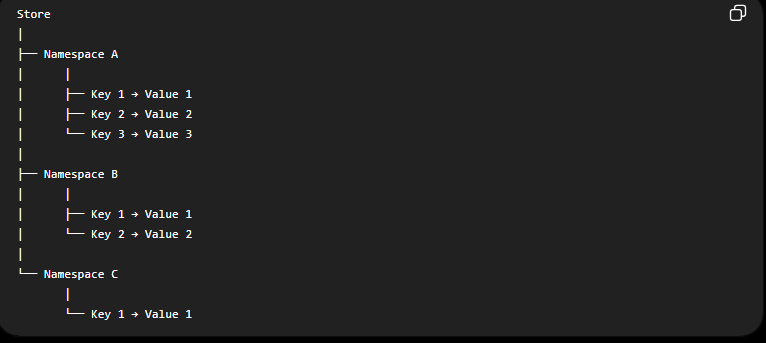

In [ ]:
def get_memory(store, namespace, default_content=None):
    """
    读取memory 如果没有就初始化一个
    
    Get memory from the store or initialize with default if it doesn't exist.
    
    Args:
        store: LangGraph BaseStore instance to search for existing memory
        namespace: Tuple defining the memory namespace, e.g. ("email_assistant", "triage_preferences")
        default_content: Default content to use if memory doesn't exist
        
    Returns:
        str: The content of the memory profile, either from existing memory or the default
    """
    # Search for existing memory with namespace and key
    user_preferences = store.get(namespace, "user_preferences")
    
    # If memory exists, return its content (the value)
    if user_preferences:
        return user_preferences.value
    
    # If memory doesn't exist, add it to the store and return the default content
    else:
        # Namespace, key, value
        store.put(namespace, "user_preferences", default_content)
        user_preferences = default_content
    
    # Return the default content
    return user_preferences 

For 2) updating memory, we can use a few tricks from the [GPT-4.1 prompting guide]((https://cookbook.openai.com/examples/gpt4-1_prompting_guide)) to help us update the memory: 

* For optimal performance, repeat the key instructions at the start and end of the prompt
* Create clear, explicit instructions 
* Use XML delimiters for structure
* Provide examples

**中文翻译：**

对于 2)，更新记忆时，可以借鉴 [GPT-4.1 prompting guide](https://cookbook.openai.com/examples/gpt4-1_prompting_guide) 中的一些技巧：

* 为了获得最佳表现，在 prompt 开头和结尾重复关键指令
* 创建清晰、明确的指令
* 使用 XML 分隔符组织结构
* 提供示例

In [ ]:

Markdown(MEMORY_UPDATE_INSTRUCTIONS)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                               Role and Objective                                                ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

You are a memory profile manager for an email assistant agent that selectively updates user preferences based on   
feedback messages from human-in-the-loop interactions with the email assistant.                                    

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                  Instructions                                                   ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

 • NEVER overwrite the entire memory profile                                                                       
 • ONLY make targeted additions of new information                                                                 
 • ONLY update specific facts that are directly contradicted by feedback messages                                  
 • PRESERVE all other existing information in the profile                                                          
 • Format the profile consistently with the original style                                                         
 • Generate the profile as a string                                                                                

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 Reasoning Steps                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

 1 Analyze the current memory profile structure and content                                                        
 2 Review feedback messages from human-in-the-loop interactions                                                    
 3 Extract relevant user preferences from these feedback messages (such as edits to emails/calendar invites,       
   explicit feedback on assistant performance, user decisions to ignore certain emails)                            
 4 Compare new information against existing profile                                                                
 5 Identify only specific facts to add or update                                                                   
 6 Preserve all other existing information                                                                         
 7 Output the complete updated profile                                                                             

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                     Example                                                     ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

<memory_profile> RESPOND:                                                                                          

 • wife                                                                                                            
 • specific questions                                                                                              
 • system admin notifications NOTIFY:                                                                              
 • meeting invites IGNORE:                                                                                         
 • marketing emails                                                                                                
 • company-wide announcements                   

In [91]:
Markdown(MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT)

Remember:                                                                                                          

 • NEVER overwrite the entire memory profile                                                                       
 • ONLY make targeted additions of new information                                                                 
 • ONLY update specific facts that are directly contradicted by feedback messages                                  
 • PRESERVE all other existing information in the profile                                                          
 • Format the profile consistently with the original style                                                         
 • Generate the profile as a string

In [ ]:
class UserPreferences(BaseModel):
    """
    规定LLM更新 Memory时必须输出什么结构
    """
    chain_of_thought: str = Field(description="Reasoning about which user preferences need to add / update if required")
    user_preferences: str = Field(description="Updated user preferences")

def update_memory(store, namespace, messages):
    """Update memory profile in the store.
    
    Args:
        store: memory 数据库
        namespace: memory的命名空间 , e.g. ("email_assistant", "triage_preferences")
        messages: 当此agent和用户 的新对话

    先把之前保存的用户信息拿出来 

    告诉llm现有的新对话 和 遗忘记录 传给他
    让llm 综合二者 生成新的memory

    把新的memory保存回store
    """

    # Get the existing memory
    # 在namespace 这个 命名空间中 找 user_performances 这个key
    user_preferences = store.get(namespace, "user_preferences")

    # Update the memory
    llm = init_chat_model("openai:gpt-4.1", temperature=0.0).with_structured_output(UserPreferences)
    result = llm.invoke(
        [
            {"role": "system", "content": MEMORY_UPDATE_INSTRUCTIONS.format(current_profile=user_preferences.value, namespace=namespace)},
        ] + messages
    )
    
    # Save the updated memory to the store
    # 这里好像是覆盖 所以每次都需要加上之前的messages
    store.put(namespace, "user_preferences", result.user_preferences)

We set up the triage router as we had before, with one small change

**中文翻译：**

我们像之前一样设置分流路由器，只做一个小改动。

In [ ]:
def triage_router(state: State, store: BaseStore) -> Command[Literal["triage_interrupt_handler", "response_agent", "__end__"]]:
    """Analyze email content to decide if we should respond, notify, or ignore.

    The triage step prevents the assistant from wasting time on:
    - Marketing emails and spam
    - Company-wide announcements
    - Messages meant for other teams
    """
    # Parse the email input
    author, to, subject, email_thread = parse_email(state["email_input"])
    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    # Create email markdown for Agent Inbox in case of notification  
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # Search for existing triage_preferences memory
    # memory 对agent 行为的影响： 改变未来决策边界
    triage_instructions = get_memory(store, ("email_assistant", "triage_preferences"), default_triage_instructions)

    # Format system prompt with background and triage instructions
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=triage_instructions,
    )

    # Run the router LLM
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )

    # Decision
    classification = result.classification

    # Process the classification decision
    if classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        # Next node
        goto = "response_agent"
        # Update the state
        update = {
            "classification_decision": result.classification,
            "messages": [{"role": "user",
                            "content": f"Respond to the email: {email_markdown}"
                        }],
        }
        
    elif classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")

        # Next node
        goto = END
        # Update the state
        update = {
            "classification_decision": classification,
        }

    elif classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information") 

        # Next node
        goto = "triage_interrupt_handler"
        # Update the state
        update = {
            "classification_decision": classification,
        }

    else:
        raise ValueError(f"Invalid classification: {classification}")
    
    return Command(goto=goto, update=update)


We only need to make a small change to the interrupt handler to update the memory when the user provides feedback.

**中文翻译：**

我们只需要对中断处理器做一个小改动：当用户提供反馈时更新记忆。

In [58]:
def triage_interrupt_handler(state: State, store: BaseStore) -> Command[Literal["response_agent", "__end__"]]:
    """Handles interrupts from the triage step"""
    
    # Parse the email input
    author, to, subject, email_thread = parse_email(state["email_input"])

    # Create email markdown for Agent Inbox in case of notification  
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # Create messages
    messages = [{"role": "user",
                "content": f"Email to notify user about: {email_markdown}"
                }]

    # Create interrupt for Agent Inbox
    request = {
        "action_request": {
            "action": f"Email Assistant: {state['classification_decision']}",
            "args": {}
        },
        "config": {
            "allow_ignore": True,  
            "allow_respond": True,
            "allow_edit": False, 
            "allow_accept": False,  
        },
        # Email to show in Agent Inbox
        "description": email_markdown,
    }

    # Send to Agent Inbox and wait for response
    response = interrupt([request])[0]

    # If user provides feedback, go to response agent and use feedback to respond to email   
    if response["type"] == "response":
        # Add feedback to messages 
        user_input = response["args"]
        messages.append({"role": "user",
                        "content": f"User wants to reply to the email. Use this feedback to respond: {user_input}"
                        })
        # This is new: update triage_preferences with feedback
        update_memory(store, ("email_assistant", "triage_preferences"), [{
            "role": "user",
            "content": f"The user decided to respond to the email, so update the triage preferences to capture this."
        }] + messages)

        goto = "response_agent"

    # If user ignores email, go to END
    elif response["type"] == "ignore":
        # Make note of the user's decision to ignore the email
        messages.append({"role": "user",
                        "content": f"The user decided to ignore the email even though it was classified as notify. Update triage preferences to capture this."
                        })
        # This is new: triage_preferences with feedback
        update_memory(store, ("email_assistant", "triage_preferences"), messages)
        goto = END

    # Catch all other responses
    else:
        raise ValueError(f"Invalid response: {response}")

    # Update the state 
    update = {
        "messages": messages,
    }

    return Command(goto=goto, update=update)

### Incorporating Memory into LLM Responses

Now that we have memory managers set up, we can use the stored preferences when generating responses

**中文翻译：**

### 将记忆纳入 LLM 回复

现在记忆管理器已经设置好，我们可以在生成回复时使用已存储的偏好。

In [59]:
def llm_call(state: State, store: BaseStore):
    """LLM decides whether to call a tool or not"""

    # Search for existing cal_preferences memory
    cal_preferences = get_memory(store, ("email_assistant", "cal_preferences"), default_cal_preferences)
    
    # Search for existing response_preferences memory
    response_preferences = get_memory(store, ("email_assistant", "response_preferences"), default_response_preferences)

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    {"role": "system", "content": agent_system_prompt_hitl_memory.format(tools_prompt=HITL_MEMORY_TOOLS_PROMPT,
                                                                                         background=default_background,
                                                                                         response_preferences=response_preferences, 
                                                                                         cal_preferences=cal_preferences)}
                ]
                + state["messages"]
            )
        ]
    }

### Memory Integration in the Interrupt Handler

Similarly, we'll add memory to the interrupt handler!

**中文翻译：**

### 中断处理器中的记忆集成

类似地，我们也会把记忆加入中断处理器。

In [60]:
def interrupt_handler(state: State, store: BaseStore) -> Command[Literal["llm_call", "__end__"]]:
    """Creates an interrupt for human review of tool calls"""
    
    # Store messages
    result = []

    # Go to the LLM call node next
    goto = "llm_call"

    # Iterate over the tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:
        
        # Allowed tools for HITL
        hitl_tools = ["write_email", "schedule_meeting", "Question"]
        
        # If tool is not in our HITL list, execute it directly without interruption
        if tool_call["name"] not in hitl_tools:

            # Execute tool without interruption
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
            continue
            
        # Get original email from email_input in state
        email_input = state["email_input"]
        author, to, subject, email_thread = parse_email(email_input)
        original_email_markdown = format_email_markdown(subject, author, to, email_thread)
        
        # Format tool call for display and prepend the original email
        tool_display = format_for_display(tool_call)
        description = original_email_markdown + tool_display

        # Configure what actions are allowed in Agent Inbox
        if tool_call["name"] == "write_email":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "schedule_meeting":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "Question":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": False,
                "allow_accept": False,
            }
        else:
            raise ValueError(f"Invalid tool call: {tool_call['name']}")

        # Create the interrupt request
        request = {
            "action_request": {
                "action": tool_call["name"],
                "args": tool_call["args"]
            },
            "config": config,
            "description": description,
        }

        # Send to Agent Inbox and wait for response
        response = interrupt([request])[0]

        # Handle the responses 
        if response["type"] == "accept":

            # Execute the tool with original args
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
                        
        elif response["type"] == "edit":

            # Tool selection 
            tool = tools_by_name[tool_call["name"]]
            initial_tool_call = tool_call["args"]
            
            # Get edited args from Agent Inbox
            edited_args = response["args"]["args"]

            # Update the AI message's tool call with edited content (reference to the message in the state)
            ai_message = state["messages"][-1] # Get the most recent message from the state
            current_id = tool_call["id"] # Store the ID of the tool call being edited
            
            # Create a new list of tool calls by filtering out the one being edited and adding the updated version
            # This avoids modifying the original list directly (immutable approach)
            updated_tool_calls = [tc for tc in ai_message.tool_calls if tc["id"] != current_id] + [
                {"type": "tool_call", "name": tool_call["name"], "args": edited_args, "id": current_id}
            ]

            # Create a new copy of the message with updated tool calls rather than modifying the original
            # This ensures state immutability and prevents side effects in other parts of the code
            # When we update the messages state key ("messages": result), the add_messages reducer will
            # overwrite existing messages by id and we take advantage of this here to update the tool calls.
            result.append(ai_message.model_copy(update={"tool_calls": updated_tool_calls}))

            # Save feedback in memory and update the write_email tool call with the edited content from Agent Inbox
            if tool_call["name"] == "write_email":
                
                # Execute the tool with edited args
                observation = tool.invoke(edited_args)
                
                # Add only the tool response message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})

                # This is new: update the memory
                update_memory(store, ("email_assistant", "response_preferences"), [{
                    "role": "user",
                    "content": f"User edited the email response. Here is the initial email generated by the assistant: {initial_tool_call}. Here is the edited email: {edited_args}. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])
            
            # Save feedback in memory and update the schedule_meeting tool call with the edited content from Agent Inbox
            elif tool_call["name"] == "schedule_meeting":
                
                # Execute the tool with edited args
                observation = tool.invoke(edited_args)
                
                # Add only the tool response message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})

                # This is new: update the memory
                update_memory(store, ("email_assistant", "cal_preferences"), [{
                    "role": "user",
                    "content": f"User edited the calendar invitation. Here is the initial calendar invitation generated by the assistant: {initial_tool_call}. Here is the edited calendar invitation: {edited_args}. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])
            
            # Catch all other tool calls
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "ignore":

            if tool_call["name"] == "write_email":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this email draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
                # This is new: update the memory
                update_memory(store, ("email_assistant", "triage_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"The user ignored the email draft. That means they did not want to respond to the email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            elif tool_call["name"] == "schedule_meeting":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this calendar meeting draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
                # This is new: update the memory
                update_memory(store, ("email_assistant", "triage_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"The user ignored the calendar meeting draft. That means they did not want to schedule a meeting for this email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            elif tool_call["name"] == "Question":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this question. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
                # This is new: update the memory
                update_memory(store, ("email_assistant", "triage_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"The user ignored the Question. That means they did not want to answer the question or deal with this email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "response":
            # User provided feedback
            user_feedback = response["args"]
            if tool_call["name"] == "write_email":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the email. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
                # This is new: update the memory
                update_memory(store, ("email_assistant", "response_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"User gave feedback, which we can use to update the response preferences. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            elif tool_call["name"] == "schedule_meeting":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the meeting request. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
                # This is new: update the memory
                update_memory(store, ("email_assistant", "cal_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"User gave feedback, which we can use to update the calendar preferences. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            elif tool_call["name"] == "Question":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User answered the question, which can we can use for any follow up actions. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})

            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

    # Update the state 
    update = {
        "messages": result,
    }

    return Command(goto=goto, update=update)

The rest is the same as before!

**中文翻译：**

其余部分和之前一样。

In [ ]:
from email_assistant.utils import show_graph

# Conditional edge function
def should_continue(state: State, store: BaseStore) -> Literal["interrupt_handler", END]:
    """Route to tool handler, or end if Done tool called"""
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "interrupt_handler"

# Build workflow
agent_builder = StateGraph(State)

# Add nodes - with store parameter
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("interrupt_handler", interrupt_handler)

# Add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "interrupt_handler": "interrupt_handler",
        END: END,
    },
)

# Compile the agent
response_agent = agent_builder.compile()

# Build overall workflow with store and checkpointer
overall_workflow = (
    StateGraph(State, input=StateInput)
    .add_node(triage_router)
    .add_node(triage_interrupt_handler)
    .add_node("response_agent", response_agent)
    .add_edge(START, "triage_router")
)

email_assistant = overall_workflow.compile()
show_graph(email_assistant)

## Testing the agent with memory

Now that we've implemented memory into our email assistant, let's test how the system learns from user feedback and adapts over time. This testing section explores how different types of user interactions create distinct memory updates that improve the assistant's future performance.

The key questions we're answering through these tests:
1. How does the system capture and store user preferences?
2. How do these stored preferences affect future decisions?
3. What patterns of interaction lead to which types of memory updates?

First, let's build a helper function to display memory content so we can track how it evolves throughout our tests:

**中文翻译：**

## 测试带记忆的智能体

现在我们已经把记忆实现到邮件助理中，接下来测试系统如何从用户反馈中学习，并随着时间推移进行适应。本测试部分会探索不同类型的用户交互如何产生不同的记忆更新，从而提升助理未来的表现。

这些测试要回答的关键问题是：
1. 系统如何捕获并存储用户偏好？
2. 这些已存储偏好如何影响未来决策？
3. 哪些交互模式会带来哪些类型的记忆更新？

首先，构建一个辅助函数来显示记忆内容，方便我们跟踪它在测试过程中的演变：

In [62]:
import uuid 
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from langgraph.store.memory import InMemoryStore

# Helper function to display memory content
def display_memory_content(store, namespace=None):
    # Display current memory content for all namespaces
    print("\n======= CURRENT MEMORY CONTENT =======")
    if namespace:
        memory = store.get(namespace, "user_preferences")
        if memory:
            print(f"\n--- {namespace[1]} ---")
            print(memory.value)
        else:
            print(f"\n--- {namespace[1]} ---")
            print("No memory found")
    else:
        for namespace in [
            ("email_assistant", "triage_preferences"),
            ("email_assistant", "response_preferences"),
            ("email_assistant", "cal_preferences"),
            ("email_assistant", "background")
        ]:
            memory = store.get(namespace, "user_preferences")
            if memory:
                print(f"\n--- {namespace[1]} ---")
                print(memory.value)
            else:
                print(f"\n--- {namespace[1]} ---")
                print("No memory found")
            print("=======================================\n")

### Accept `write_email` and `schedule_meeting`

Our first test examines what happens when a user accepts the agent's actions without modification. This baseline case helps us understand how the system behaves when no feedback is provided:

1. We'll use the same tax planning email from our previous tests
2. The system will classify it as "RESPOND" and propose scheduling a meeting
3. We'll accept the meeting schedule without changes
4. The agent will generate an email confirming the meeting
5. We'll accept the email without changes

This test demonstrates the default behavior of our memory-enabled system. When a user simply accepts proposed actions, we expect minimal or no memory updates since there's no explicit feedback to learn from. However, the system will still leverage existing memory (if any) when generating its responses.

**中文翻译：**

### 接受 `write_email` 和 `schedule_meeting`

第一个测试检查当用户不做修改、直接接受智能体动作时会发生什么。这个基线用例帮助我们理解在没有反馈时系统如何表现：

1. 我们会使用和之前测试相同的税务规划邮件
2. 系统会把它分类为 "RESPOND"，并提出安排会议
3. 我们会不做更改地接受会议安排
4. 智能体会生成确认会议的邮件
5. 我们会不做更改地接受这封邮件

这个测试展示了启用记忆后的系统默认行为。当用户只是接受建议动作时，我们预期记忆更新很少，甚至没有更新，因为没有显式反馈可供学习。不过，系统在生成回复时仍会利用已有记忆（如果存在）。

In [ ]:
# Respond - Meeting Request Email
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager"
}

# Compile the graph
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_1 = uuid.uuid4()
thread_config_1 = {"configurable": {"thread_id": thread_id_1}}

# Run the graph until the first interrupt 
# Email will be classified as "respond" 
# Agent will create a schedule_meeting and write_email tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_1):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after first interrupt
display_memory_content(store)

Accept the `schedule_meeting` tool call

As we examine the initial `schedule_meeting` proposal, note how the system uses existing memory to inform its decisions:

1. The default calendar preferences show a preference for 30-minute meetings, though the email requests 45 minutes
2. The agent still proposes a 45-minute meeting, respecting the sender's specific request
3. We accept this proposal without modification to see if simple acceptance triggers any memory updates

After running this step, we'll check the memory contents to confirm whether acceptance alone leads to memory updates. Simple acceptance represents the baseline user experience - the system works as intended without requiring adjustments.

**中文翻译：**

接受 `schedule_meeting` 工具调用

在查看初始 `schedule_meeting` 建议时，请注意系统如何使用已有记忆来辅助决策：

1. 默认日历偏好显示更偏好 30 分钟会议，虽然邮件请求 45 分钟
2. 智能体仍然建议 45 分钟会议，尊重发件人的具体请求
3. 我们不做修改地接受该建议，看看简单接受是否触发记忆更新

运行这一步后，我们会检查记忆内容，确认仅仅接受是否会导致记忆更新。简单接受代表基线用户体验：系统按预期工作，无需用户调整。

In [ ]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_1):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

Accept the `write_email` tool call

Now we'll accept the email draft that confirms the meeting scheduling:

1. The email draft is generated with knowledge of our calendar preferences
2. It includes details about the meeting time, duration, and purpose
3. We'll accept it without changes to complete the baseline test case

After accepting, we'll check all memory stores to see if any updates occurred. As expected, simply accepting the agent's proposals doesn't provide strong learning signals - there's no clear feedback about what the user likes or dislikes about the agent's approach.

The trace link shows the complete workflow execution, where we can see that the memory is used in the LLM call for response generation, but no memory updates occur, which is the expected behavior for simple acceptances.

**中文翻译：**

接受 `write_email` 工具调用

现在我们接受确认会议安排的邮件草稿：

1. 邮件草稿生成时使用了我们的日历偏好
2. 它包含会议时间、时长和目的等细节
3. 我们会不做更改地接受它，从而完成基线测试用例

接受后，我们会检查所有记忆 store，看看是否发生了更新。正如预期，单纯接受智能体建议不会提供强学习信号，因为没有关于用户喜欢或不喜欢智能体处理方式的明确反馈。

trace 链接展示了完整工作流执行过程。我们可以看到，记忆被用于生成回复的 LLM 调用，但没有发生记忆更新；这正是简单接受时的预期行为。

In [ ]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_1):
    # Inspect response_agent most recent message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after accepting the write_email tool call
display_memory_content(store)

We can look at the full messages, and the trace: 

https://smith.langchain.com/public/86ff6474-29fe-452e-8829-b05a91b458eb/r

You'll notice that memory is used in the LLM call to respond. 

But the memory store is *not* updated, because we haven't added any feedback via HITL.

**中文翻译：**

我们可以查看完整消息和 trace：

https://smith.langchain.com/public/86ff6474-29fe-452e-8829-b05a91b458eb/r

你会注意到，记忆被用于 LLM 调用以生成回复。

但 memory store *没有*被更新，因为我们还没有通过 HITL 添加任何反馈。

In [ ]:
state = graph.get_state(thread_config_1)
for m in state.values['messages']:
    m.pretty_print()

### Edit `write_email` and `schedule_meeting`

This test explores how the system learns from direct edits to its proposed actions. When users modify the agent's suggestions, it creates clear, specific learning signals about their preferences:

1. We'll use the same tax planning email as before
2. When the agent proposes a 45-minute meeting, we'll edit it to:
   - Change the duration to 30 minutes (matching our stored preference)
   - Make the subject line more concise
3. When the agent drafts an email, we'll edit it to be:
   - Shorter and less formal
   - Structured differently

Edits provide the most explicit feedback about user preferences, letting the system learn exactly what changes are desired. We expect to see specific, targeted updates to our memory stores that reflect these edits.

**中文翻译：**

### 编辑 `write_email` 和 `schedule_meeting`

这个测试探索系统如何从对拟执行动作的直接编辑中学习。当用户修改智能体建议时，会产生清晰、具体的偏好学习信号：

1. 我们会使用和之前相同的税务规划邮件
2. 当智能体提出 45 分钟会议时，我们会编辑它：
   - 把时长改为 30 分钟，匹配已存储偏好
   - 让主题行更简洁
3. 当智能体起草邮件时，我们会编辑它，使其：
   - 更短、更不正式
   - 结构有所不同

编辑提供了关于用户偏好的最显式反馈，让系统准确学习期望的变化。我们预期会看到对记忆 store 的具体、有针对性的更新，反映这些编辑。

In [ ]:
# Same email as before
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager"
}

# Compile the graph with new thread
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_2 = uuid.uuid4()
thread_config_2 = {"configurable": {"thread_id": thread_id_2}}

# Run the graph until the first interrupt - will be classified as "respond" and the agent will create a write_email tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_2):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after first interrupt
display_memory_content(store,("email_assistant", "cal_preferences"))

Edit the `schedule_meeting` tool call

When we edit the meeting proposal, we're providing direct, explicit feedback about our preferences. This creates a significant learning opportunity for the system:

1. The agent initially proposes a 45-minute meeting (the duration requested in the email)
2. We edit it to 30 minutes and simplify the subject from "Tax Planning Strategies Discussion" to "Tax Planning Discussion"
3. This creates clear, specific feedback about our time preferences and naming conventions

After the edit, we'll check the calendar preferences memory store to see how it's updated. The memory update should capture both:
- Our preference for shorter 30-minute meetings
- Our preference for more concise meeting subjects

The trace reveals the precise memory update logic, showing how the system analyzes the difference between its proposal and our edits to extract meaningful patterns and preferences. We can see the detailed justification for each memory update, ensuring transparency in the learning process.

**中文翻译：**

编辑 `schedule_meeting` 工具调用

当我们编辑会议建议时，就是在提供关于自身偏好的直接、明确反馈。这为系统创造了重要学习机会：

1. 智能体最初建议 45 分钟会议，这是邮件中请求的时长
2. 我们把它编辑为 30 分钟，并把主题从 "Tax Planning Strategies Discussion" 简化为 "Tax Planning Discussion"
3. 这产生了关于时间偏好和命名习惯的清晰具体反馈

编辑后，我们会检查日历偏好 memory store，看看它如何更新。记忆更新应该捕获两点：
- 我们偏好更短的 30 分钟会议
- 我们偏好更简洁的会议主题

trace 会揭示精确的记忆更新逻辑，展示系统如何分析其建议与我们编辑之间的差异，从而提取有意义的模式和偏好。我们可以看到每次记忆更新的详细理由，确保学习过程透明。

In [ ]:
# Now simulate user editing the schedule_meeting tool call
print("\nSimulating user editing the schedule_meeting tool call...")
edited_schedule_args = {
    "attendees": ["pm@client.com", "lance@company.com"],
    "subject": "Tax Planning Discussion",
    "duration_minutes": 30, # Changed from 45 to 30
    "preferred_day": "2025-04-22",
    "start_time": 14 
}
for chunk in graph.stream(Command(resume=[{"type": "edit", "args": {"args": edited_schedule_args}}]), config=thread_config_2):
    # Inspect response_agent most recent message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after editing schedule_meeting
print("\nChecking memory after editing schedule_meeting:")
display_memory_content(store,("email_assistant", "cal_preferences"))

```
{'preferences': '\n30 minute meetings are preferred, but 15 minute meetings are also acceptable.\n'}
```

```
{'preferences': "30 minute meetings are preferred, but 15 minute meetings are also acceptable.\n\nUser prefers 30 minute meetings over longer durations such as 45 minutes. When scheduling, default to 30 minutes unless otherwise specified. Subject lines should be concise (e.g., 'Tax Planning Discussion' instead of 'Tax Planning Strategies Discussion')."}
```

**中文翻译：**

```
{'preferences': '
偏好 30 分钟会议，但 15 分钟会议也可以接受。
'}
```

```
{'preferences': "偏好 30 分钟会议，但 15 分钟会议也可以接受。

用户偏好 30 分钟会议，而不是 45 分钟等更长时长。安排会议时，除非另有说明，默认使用 30 分钟。主题行应简洁，例如使用 'Tax Planning Discussion'，而不是 'Tax Planning Strategies Discussion'。"}
```

Looking at the memory after editing the calendar invitation, we can see that it's been updated:

1. The system has identified that we prefer 30-minute meetings over longer durations
2. It's also captured our preference for concise meeting subjects

What's particularly impressive about this memory update is:
- It doesn't just record our specific edit, but generalizes to a broader preference pattern
- It preserves all existing memory content while adding the new information
- It extracts multiple preference signals from a single edit interaction

Now, let's edit the email draft to see how the system captures different types of communication preferences:

**中文翻译：**

查看编辑日历邀请后的记忆，可以看到它已经被更新：

1. 系统识别出我们更偏好 30 分钟会议，而不是更长时长
2. 它也捕获了我们对简洁会议主题的偏好

这次记忆更新特别值得注意的地方是：
- 它不是只记录具体编辑，而是概括为更广泛的偏好模式
- 它在添加新信息的同时保留了所有已有记忆内容
- 它从一次编辑交互中提取了多个偏好信号

现在，让我们编辑邮件草稿，看看系统如何捕获不同类型的沟通偏好：

In [ ]:
display_memory_content(store,("email_assistant", "response_preferences"))
# Now simulate user editing the write_email tool call
print("\nSimulating user editing the write_email tool call...")
edited_email_args = {
    "to": "pm@client.com",
    "subject": "Re: Tax season let's schedule call",
    "content": "Thanks! I scheduled a 30-minute call next Thursday at 3:00 PM. Would that work for you?\n\nBest regards,\nLance Martin"
}
for chunk in graph.stream(Command(resume=[{"type": "edit", "args": {"args": edited_email_args}}]), config=thread_config_2):
    # Inspect response_agent most recent message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after editing write_email
print("\nChecking memory after editing write_email:")
display_memory_content(store,("email_assistant", "response_preferences"))

Our email edit reveals even more sophisticated learning capabilities:

1. We've dramatically shortened and simplified the email content
2. We've changed the tone to be more casual
3. We've added a question asking for confirmation rather than assuming the time works
4. We've slightly altered the meeting details (day and time)

Looking at the updated memory, we can see that the system has extracted a key insight about our communication style:

```
When scheduling a meeting, ask the recipient to confirm if the proposed time works for them, rather than assuming and stating the meeting is already scheduled.
```

This demonstrates the system's ability to:
- Analyze our edit not just at a superficial level, but to understand intent
- Extract generalizable principles from specific examples
- Preserve all existing guidance while adding new insights
- Maintain the organization and structure of the memory

These targeted, high-quality memory updates will improve all future interactions without requiring repeated corrections.

**中文翻译：**

我们的邮件编辑展示了更复杂的学习能力：

1. 我们大幅缩短并简化了邮件内容
2. 我们把语气改得更随意
3. 我们添加了一个询问确认的问题，而不是假设该时间可行
4. 我们略微修改了会议细节，例如日期和时间

查看更新后的记忆，可以看到系统提取了一个关于沟通风格的关键洞察：

```
安排会议时，应该询问收件人拟议时间是否可行，而不是假设并声明会议已经安排好。
```

这展示了系统的能力：
- 不只在表层分析我们的编辑，而是理解意图
- 从具体示例中提取可泛化原则
- 在添加新洞察的同时保留所有已有指导
- 维持记忆的组织和结构

这些有针对性的高质量记忆更新，会改善未来所有交互，并减少重复纠正。

In [ ]:
state = graph.get_state(thread_config_2)
for m in state.values['messages']:
    m.pretty_print()

### Respond (with feedback) `write_email` and `schedule_meeting`

Our final test set explores the "response" feedback pattern - providing guidance without directly editing or accepting. This conversational feedback mechanism offers a middle ground between acceptance and editing:

1. First, we'll test feedback for meeting scheduling by requesting:
   - Shorter duration (30 minutes instead of 45)
   - Afternoon meeting times (after 2pm)
   
2. Next, we'll test feedback for email drafting by requesting:
   - Shorter, less formal language
   - A specific closing statement about looking forward to the meeting
   
3. Finally, we'll test feedback for questions by providing:
   - A direct answer with additional context
   - Specific preferences (brunch location, time)

This natural language feedback approach lets users guide the assistant without having to do the work themselves. We expect to see detailed memory updates that extract the general principles from our specific feedback.

**中文翻译：**

### 响应（提供反馈）`write_email` 和 `schedule_meeting`

最后一组测试探索 "response" 反馈模式，即不直接编辑也不直接接受，而是提供指导。这种对话式反馈机制介于接受和编辑之间：

1. 首先，我们会测试会议安排反馈，请求：
   - 更短时长，30 分钟而不是 45 分钟
   - 下午会议时间，2 点以后

2. 接着，我们会测试邮件起草反馈，请求：
   - 更短、更不正式的语言
   - 一句关于期待会议的特定结尾

3. 最后，我们会测试针对问题的反馈，提供：
   - 带额外上下文的直接回答
   - 具体偏好，例如早午餐地点和时间

这种自然语言反馈方式让用户可以指导助理，而不必亲自完成所有工作。我们预期会看到详细的记忆更新，从具体反馈中提取通用原则。

In [ ]:
# Respond - Meeting Request Email
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager"
}

# Compile the graph
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_5 = uuid.uuid4()
thread_config_5 = {"configurable": {"thread_id": thread_id_5}}

# Run the graph until the first interrupt 
# Email will be classified as "respond" 
# Agent will create a schedule_meeting and write_email tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_5):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after first interrupt 
display_memory_content(store, ("email_assistant", "cal_preferences"))

Provide feedback for the `schedule_meeting` tool call

Instead of directly editing the meeting proposal or simply accepting it, we'll provide natural language feedback:

1. We request a 30-minute meeting instead of 45 minutes
2. We express a preference for afternoon meetings after 2pm
3. The system must interpret this feedback and generate a new proposal

This conversational approach is often more natural and efficient than direct editing, especially for mobile users or those who prefer to give high-level direction rather than detailed edits.

After providing feedback, we'll examine the calendar preferences memory to see how this natural language guidance is captured. We expect to see the system extract both the meeting duration and time-of-day preferences as general principles.

**中文翻译：**

为 `schedule_meeting` 工具调用提供反馈

我们不直接编辑会议建议，也不只是接受它，而是提供自然语言反馈：

1. 我们请求 30 分钟会议，而不是 45 分钟
2. 我们表达对下午 2 点以后会议的偏好
3. 系统必须解释这条反馈，并生成新的建议

这种对话式方式通常比直接编辑更自然、更高效，尤其适合移动端用户，或更喜欢给出高层方向而不是细节编辑的用户。

提供反馈后，我们会检查日历偏好记忆，看看这条自然语言指导如何被捕获。我们预期系统会把会议时长和一天中时间偏好都提取为通用原则。

In [ ]:
print(f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "response", "args": "Please schedule this for 30 minutes instead of 45 minutes, and I prefer afternoon meetings after 2pm."}]), config=thread_config_5):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after providing feedback for schedule_meeting
print("\nChecking memory after providing feedback for schedule_meeting:")
display_memory_content(store, ("email_assistant", "cal_preferences"))

Our memory check after providing feedback shows an elegantly simple calendar preference update:

```
30 minute meetings are preferred, but 15 minute meetings are also acceptable.
Afternoon meetings after 2pm are preferred.
```

The system has:
1. Captured both aspects of our feedback (duration and time of day)
2. Preserved the existing preference about 15-minute meetings
3. Added our preference for afternoon meetings after 2pm as a new line
4. Kept the format clean and readable

This natural language feedback mechanism creates the same quality of memory updates as direct editing but requires less effort from the user. The system is able to extract structured preferences from unstructured feedback, showing its ability to learn from conversational interactions.

Let's accept this revised meeting proposal and move to the email draft:

**中文翻译：**

提供反馈后的记忆检查显示了一个简洁的日历偏好更新：

```
偏好 30 分钟会议，但 15 分钟会议也可以接受。
偏好下午 2 点以后的会议。
```

系统已经：
1. 捕获了反馈的两个方面，即时长和一天中的时间
2. 保留了关于 15 分钟会议的已有偏好
3. 将下午 2 点以后会议的偏好作为新行添加
4. 保持格式干净易读

这种自然语言反馈机制能产生与直接编辑相同质量的记忆更新，但用户付出的努力更少。系统能够从非结构化反馈中提取结构化偏好，体现了从对话交互中学习的能力。

让我们接受这个修订后的会议建议，并进入邮件草稿：

In [ ]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_5):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after accepting schedule_meeting after feedback
print("\nChecking memory after accepting schedule_meeting after feedback:")
display_memory_content(store, ("email_assistant", "response_preferences"))

Now provide feedback for the `write_email` tool call

Similar to our meeting feedback, we'll now provide natural language guidance for the email draft:

1. We request "shorter and less formal" language - a style preference
2. We ask for a specific closing statement about looking forward to the meeting
3. The system must interpret this guidance and rewrite the email accordingly

After providing this feedback, we'll check the response preferences memory to see how these style and structure preferences are captured. We expect to see generalizable guidelines about email brevity, formality, and closing statements added to our preference profile.

**中文翻译：**

现在为 `write_email` 工具调用提供反馈

和会议反馈类似，我们现在对邮件草稿提供自然语言指导：

1. 我们要求语言“更短、更不正式”，这是一种风格偏好
2. 我们要求加入一句关于期待会议的特定结尾
3. 系统必须解释这些指导，并相应重写邮件

提供反馈后，我们会检查回复偏好记忆，看看这些风格和结构偏好如何被捕获。我们预期会看到关于邮件简洁度、正式程度和结尾语的可泛化准则被添加到偏好档案中。

In [ ]:
print(f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "response", "args": "Shorter and less formal. Include a closing statement about looking forward to the meeting!"}]), config=thread_config_5):
    # Inspect response_agent most recent message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after providing feedback for write_email
print("\nChecking memory after providing feedback for write_email:")
display_memory_content(store, ("email_assistant", "response_preferences"))

The memory update after our email feedback shows highly sophisticated learning about both meeting scheduling and email writing preferences:

1. The system has added a complete new section to the response preferences entitled "When writing email responses" with two key preferences:
   - "Favor shorter and less formal language when possible, unless the context requires formality"
   - "Include a closing statement expressing that you look forward to the meeting or conversation when confirming appointments"

2. It has also added a new bullet point to the "When responding to meeting scheduling requests" section:
   - "When scheduling meetings, prefer afternoon times after 2pm when possible, and default to 30-minute durations unless otherwise specified"

This demonstrates the system's ability to:
- Organize learned preferences into appropriate categories
- Extract multiple insights from a single feedback instance
- Apply meeting preferences to both calendar and email contexts
- Capture nuance with appropriate qualifiers ("when possible," "unless otherwise specified")
- Maintain the hierarchical structure of the memory

The resulting email shows all these preferences applied: it's shorter, less formal, includes a closing statement about looking forward to the chat, and correctly references the 30-minute meeting time.

**中文翻译：**

邮件反馈后的记忆更新显示，系统对会议安排和邮件写作偏好都有了高度复杂的学习：

1. 系统在回复偏好中新增了一个完整小节，标题为 "When writing email responses"，其中包含两个关键偏好：
   - "Favor shorter and less formal language when possible, unless the context requires formality"
   - "Include a closing statement expressing that you look forward to the meeting or conversation when confirming appointments"

2. 它还在 "When responding to meeting scheduling requests" 小节中新增了一个要点：
   - "When scheduling meetings, prefer afternoon times after 2pm when possible, and default to 30-minute durations unless otherwise specified"

这展示了系统的能力：
- 将学习到的偏好组织进合适类别
- 从一次反馈中提取多个洞察
- 把会议偏好同时应用到日历和邮件语境
- 用合适限定语捕获细微差别，例如“在可能时”“除非另有说明”
- 维持记忆的层级结构

最终邮件体现了所有这些偏好：更短、更不正式，包含关于期待聊天的结尾语，并正确引用 30 分钟会议时间。

In [ ]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_5):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# Check memory after accepting write_email after feedback
print("\nChecking memory after accepting write_email after feedback:")
display_memory_content(store, ("email_assistant", "response_preferences"))

Look at the full message history.

**中文翻译：**

查看完整消息历史。

In [ ]:
state = graph.get_state(thread_config_5)
for m in state.values['messages']:
    m.pretty_print()

## Local Deployment

You can find this graph with memory integration in the `src/email_assistant` directory:

* `src/email_assistant/email_assistant_hitl_memory.py`

**中文翻译：**

## 本地部署

你可以在 `src/email_assistant` 目录中找到带记忆集成的图：

* `src/email_assistant/email_assistant_hitl_memory.py`

Email to test: 
```
{
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice"
}
```

As before, if you go to [dev.agentinbox.ai](https://dev.agentinbox.ai/), you can easily connect to the graph:

   * Graph name: the name from the `langgraph.json` file (`email_assistant_hitl_memory`)
   * Graph URL: `http://127.0.0.1:2024/`

![inbox](img/agent-inbox-edit.png)

**中文翻译：**

用于测试的邮件：
```
{
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John,
I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?
Specifically, I'm looking at:
- /auth/refresh
- /auth/validate
Thanks!
Alice"
}
```

和之前一样，如果访问 [dev.agentinbox.ai](https://dev.agentinbox.ai/)，可以很容易连接到图：

   * Graph name：`langgraph.json` 文件中的名称，也就是 `email_assistant_hitl_memory`
   * Graph URL：`http://127.0.0.1:2024/`

![inbox](img/agent-inbox-edit.png)

The Memory tab in LangGraph Studio offers a real-time view of how your preferences are being captured and updated with each interaction:

![studio-img](img/memory-studio.png)

Through continued use, the system becomes increasingly personalized:
- It learns which emails you want to respond to, be notified about, or ignore
- It adapts to your communication style preferences
- It remembers your scheduling preferences
- It refines its understanding with each interaction

This combination of HITL and memory creates a system that balances automation with control - handling routine tasks automatically while learning from your feedback to become more aligned with your preferences over time.

**中文翻译：**

LangGraph Studio 中的 Memory 标签页可以实时展示你的偏好如何随着每次交互被捕获和更新：

![studio-img](img/memory-studio.png)

随着持续使用，系统会变得越来越个性化：
- 它会学习你希望回复、收到通知或忽略哪些邮件
- 它会适应你的沟通风格偏好
- 它会记住你的日程安排偏好
- 它会在每次交互中细化理解

HITL 与记忆的结合创建了一个在自动化和控制之间取得平衡的系统：它自动处理常规任务，同时从你的反馈中学习，从而随着时间推移更贴合你的偏好。

## Hosted Deployment with Gmail Tools

If you want to actually run this on your own email, you can deploy the graph with Gmail tools. 

Set up your Gmail credentials [following here](https://github.com/langchain-ai/agents-from-scratch/blob/main/src/email_assistant/tools/gmail/README.md).

There is a graph set up with Gmail tools:

```shell
python src/email_assistant/email_assistant_hitl_memory_gmail.py
```

[One of the deployment options is `hosted`](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options), and you can simply connect the deployed graph URL to the Agent Inbox as done with the local deployment.

## Improving Memory 

Our current memory schema and updating is extremely simple: 

* Our schema is a string
* We always overwrite the existing memory with a new string
 
The store can be easily [configured for semantic search](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/) over a collection of memories. 

Also consider using [LangMem](https://langchain-ai.github.io/langmem/) for more advanced memory management.

**中文翻译：**

## 使用 Gmail 工具的托管部署

如果你想真正让它处理自己的邮件，可以部署带 Gmail 工具的图。

按照[这里](https://github.com/langchain-ai/agents-from-scratch/blob/main/src/email_assistant/tools/gmail/README.md)的说明设置 Gmail 凭据。

已经有一个配置好 Gmail 工具的图：

```shell
python src/email_assistant/email_assistant_hitl_memory_gmail.py
```

[部署选项之一是 `hosted`](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options)，你可以像本地部署一样，把已部署图的 URL 连接到 Agent Inbox。

## 改进记忆

当前的记忆 schema 和更新方式极其简单：

* schema 是一个字符串
* 我们总是用新字符串覆盖已有记忆

store 可以很容易地[配置为对记忆集合进行语义搜索](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/)。

也可以考虑使用 [LangMem](https://langchain-ai.github.io/langmem/) 进行更高级的记忆管理。